In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [3]:
import math
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.pyplot import imread
import scipy
from PIL import Image
import pandas as pd
import tensorflow as tf
import tensorflow.keras.layers as tfl
from tensorflow.python.framework import ops
from cnn_utils import *
from test_utils import summary, comparator

%matplotlib inline
np.random.seed(1)

In [4]:
X_train_orig, Y_train_orig, X_test_orig, Y_test_orig, classes = load_dataset()

X_train = X_train_orig/255
X_test = X_test_orig/255

Y_train = Y_train_orig.T
Y_test = Y_test_orig.T

print("number of training examples = " + str(X_train.shape[0]))
print("number of test examples = " + str(X_test.shape[0]))
print("X_train shape = " + str(X_train.shape))
print("X_test shape = " + str(X_test.shape))
print("Y_train shape = " + str(Y_train.shape))
print("Y_test shape = " + str(Y_test.shape))

number of training examples = 600
number of test examples = 150
X_train shape = (600, 64, 64, 3)
X_test shape = (150, 64, 64, 3)
Y_train shape = (600, 1)
Y_test shape = (150, 1)


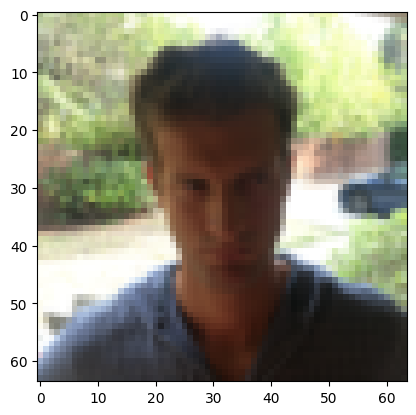

In [5]:
index = 200
plt.imshow(X_train_orig[index])
plt.show()

# The Sequential API

Create the Sequential Model

1. happyModel

In [6]:
def happyMOdel():
    """
    Implements the forward propagation for the binary classificaition model:
    ZEROPAD2D -> CONV2D -> BATCHNORM -> RELU -> MAXPOOL -> FLATTEN -> DENSE

    Note that for simplicity and grading purpose, you'll hard-code all the values such as
    the stride and kernel (filter) sizes.
    Normally, functions should take these values as function parameters.

    Arguments:
    None

    Returns:
    model -- TF keras model (object containing the information for the entire training process)
    """

    model = tf.keras.Sequential([
        tf.keras.layers.ZeroPadding2D(padding=(3, 3), input_shape=(64, 64, 3), data_format="channels_last", ),

        tf.keras.layers.Conv2D(32, (7, 7), strides=(1, 1), name="conv8"),

        tf.keras.layers.BatchNormalization(axis=3, name="bn0"),

        tf.keras.layers.ReLU(max_value=None, negative_slope=0.0, threshold=0.0),

        tf.keras.layers.MaxPool2D((2, 2), name='max_pool0'),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(1, activation="sigmoid", name="fc")
    ])

    return model

In [7]:
happy_model = happyMOdel()

for layer in summary(happy_model):
    print(layer)

output = [['ZeroPadding2D', (None, 70, 70, 3), 0, ((3, 3), (3, 3))],
          ['Conv2D', (None, 64, 64, 32), 4736, 'valid', 'linear', 'GlorotUniform'],
          ['BatchNormalization', (None, 64, 64, 32), 128],
          ['ReLU', (None, 64, 64, 32), 0],
          ['MaxPooling2D', (None, 32, 32, 32), 0, (2, 2), (2, 2), 'valid'],
          ['Flatten', (None, 32768), 0],
          ['Dense', (None, 1), 32769, 'sigmoid']]

comparator(summary(happy_model), output)

/home/neville/Documents/Programming/Artificial_Intelligence/AI_ML/ml/lib/python3.12/site-packages/keras/src/layers/reshaping/zero_padding2d.py:72: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1781452721.646908    5506 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1781452721.647686    8729 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1781452721.685903    5506 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you woul

['ZeroPadding2D', (None, 70, 70, 3), 0, ((3, 3), (3, 3))]
['Conv2D', (None, 64, 64, 32), 4736, 'valid', 'linear', 'GlorotUniform']
['BatchNormalization', (None, 64, 64, 32), 128]
['ReLU', (None, 64, 64, 32), 0]
['MaxPooling2D', (None, 32, 32, 32), 0, (2, 2), (2, 2), 'valid']
['Flatten', (None, 32768), 0]
['Dense', (None, 1), 32769, 'sigmoid']
All tests passed!


In [8]:
happy_model.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

In [9]:
happy_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ zero_padding2d (ZeroPadding2D)  │ (None, 70, 70, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv8 (Conv2D)                  │ (None, 64, 64, 32)     │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn0 (BatchNormalization)        │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool0 (MaxPooling2D)        │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc (Dense)                      │ (None, 1)              │        32,769 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,633 (147.00 KB)

 Trainable params: 37,569 (146.75 KB)

 Non-trainable params: 64 (256.00 B)

In [10]:
happy_model.fit(X_train, Y_train, epochs=10, batch_size=16)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.6917 - loss: 1.3489
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.8933 - loss: 0.3008
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.9217 - loss: 0.1779
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.9417 - loss: 0.1358
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.9667 - loss: 0.1121
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.9583 - loss: 0.1176
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.9600 - loss: 0.0940
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.9833 - loss: 0.0608
Epoch 9/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.9767 - loss: 0.0750
Epoch 10/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.9583 - loss: 0.0964


In [11]:
happy_model.evaluate(X_test, Y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9533 - loss: 0.1347


[0.1346801072359085, 0.95333331823349]

# The Functional API

Load the SIGNS Dataset

In [12]:
X_train_orig, Y_train_orig, X_test_orig, Y_test_orig, classes = load_signs_dataset()

y = 4


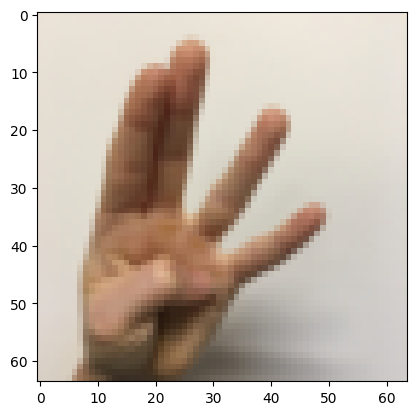

In [13]:
index = 9
plt.imshow(X_train_orig[index])
print("y = " + str(np.squeeze(Y_train_orig[:, index])))

Split the Data into Train/Test Sets

In [14]:
X_train = X_train_orig/255.
X_test = X_test_orig/255.
Y_train = convert_to_one_hot(Y_train_orig, 6).T
Y_test = convert_to_one_hot(Y_test_orig, 6).T
print("number of training examples = " + str(X_train.shape[0]))
print("number of test examples = " + str(X_test.shape[0]))
print("X_train shape: " + str(X_train.shape))
print("Y_train shape: " + str(Y_train.shape))
print("X_test shape: " + str(X_test.shape))
print("Y_test shape: " + str(Y_test.shape))

number of training examples = 1080
number of test examples = 120
X_train shape: (1080, 64, 64, 3)
Y_train shape: (1080, 6)
X_test shape: (120, 64, 64, 3)
Y_test shape: (120, 6)


In [15]:
def convolutional_model(input_shape):
    """
    Implements the forward propagation for the model:
    CONV2D -> RELU -> MAXPOOL -> CONV2D -> RELU -> MAXPOOL -> FLATTEN -> DENSE

    Note that for simplicity and grading purposes, you'll hard-code some values such as the stride and kernel (filter) sizes.
    Normally, functions should take these values a function parameters.

    Arguments:
    input_img -- input dataset, of shape (input_shape)

    Returns:
    model -- TF Keras model (object containing the information for the entire training process)
    """

    input_img = tf.keras.Input(shape=input_shape)

    Z1 = tf.keras.layers.Conv2D(filters=8, kernel_size=(4, 4), strides=(1, 1), padding='same')(input_img)
    A1 = tf.keras.layers.ReLU()(Z1)
    P1 = tf.keras.layers.MaxPool2D(pool_size=(8, 8), strides=(8, 8), padding='same')(A1)
    Z2 = tf.keras.layers.Conv2D(filters=16, kernel_size=(2, 2), strides=(1, 1), padding='same')(P1)
    A2 = tf.keras.layers.ReLU()(Z2)
    P2 = tf.keras.layers.MaxPool2D(pool_size=(4, 4), strides=(4, 4), padding='same')(A2)
    F = tf.keras.layers.Flatten()(P2)

    output_img = tf.keras.layers.Dense(units=6, activation='softmax')(F)

    model = tf.keras.Model(inputs=input_img, outputs=output_img)

    return model

In [18]:
conv_model = convolutional_model((64, 64, 3))
conv_model.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])
conv_model.summary()

output = [['InputLayer', (None, 64, 64, 3), 0],
          ['Conv2D', (None, 64, 64, 8), 392, 'same', 'linear', 'GlorotUniform'],
          ['ReLU', (None, 64, 64, 8), 0],
          ['MaxPooling2D', (None, 8, 8, 8), 0, (8, 8), (8, 8), 'same'],
          ['Conv2D', (None, 8, 8, 16), 528, 'same', 'linear', 'GlorotUniform'],
          ['ReLU', (None, 8, 8, 16), 0],
          ['MaxPooling2D', (None, 2, 2, 16), 0, (4, 4), (4, 4), 'same'],
          ['Flatten', (None, 64), 0],
          ['Dense', (None, 6), 390, 'softmax']]

comparator(summary(conv_model), output)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 8)      │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 64, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 16)       │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,310 (5.12 KB)

 Trainable params: 1,310 (5.12 KB)

 Non-trainable params: 0 (0.00 B)

All tests passed!


In [19]:
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).batch(64)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, Y_test)).batch(64)
history = conv_model.fit(train_dataset, epochs=100, validation_data=test_dataset)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.1657 - loss: 1.8045 - val_accuracy: 0.1583 - val_loss: 1.7920
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.1870 - loss: 1.7894 - val_accuracy: 0.2167 - val_loss: 1.7836
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.2454 - loss: 1.7831 - val_accuracy: 0.2250 - val_loss: 1.7783
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.2611 - loss: 1.7783 - val_accuracy: 0.3000 - val_loss: 1.7733
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.3056 - loss: 1.7718 - val_accuracy: 0.3750 - val_loss: 1.7669
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.3093 - loss: 1.7648 - val_accuracy: 0.3417 - val_loss: 1.7591
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.3343 - loss: 1.7557 - val_accuracy: 0.3833 - val_loss: 1.7505
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.3769 - loss: 1.7439 - val_accuracy: 0.

History Object

In [20]:
history.history

{'accuracy': [0.1657407432794571,
  0.18703703582286835,
  0.24537037312984467,
  0.2611111104488373,
  0.3055555522441864,
  0.3092592656612396,
  0.3342592716217041,
  0.3768518567085266,
  0.385185182094574,
  0.4148148000240326,
  0.4277777671813965,
  0.4472222328186035,
  0.4601851999759674,
  0.47685185074806213,
  0.48240742087364197,
  0.5092592835426331,
  0.5175926089286804,
  0.5425925850868225,
  0.5472221970558167,
  0.5703703761100769,
  0.5833333134651184,
  0.6018518805503845,
  0.6111111044883728,
  0.6138888597488403,
  0.6222222447395325,
  0.6287037134170532,
  0.6425926089286804,
  0.6509259343147278,
  0.6564815044403076,
  0.6694444417953491,
  0.6805555820465088,
  0.6842592358589172,
  0.6935185194015503,
  0.6990740895271301,
  0.7046296000480652,
  0.7074074149131775,
  0.7120370268821716,
  0.7185184955596924,
  0.7240740656852722,
  0.729629635810852,
  0.7351852059364319,
  0.7379629611968994,
  0.7416666746139526,
  0.7425925731658936,
  0.75,
  0.751851

[Text(0.5, 0, 'Epoch'), Text(0, 0.5, 'Accuracy')]

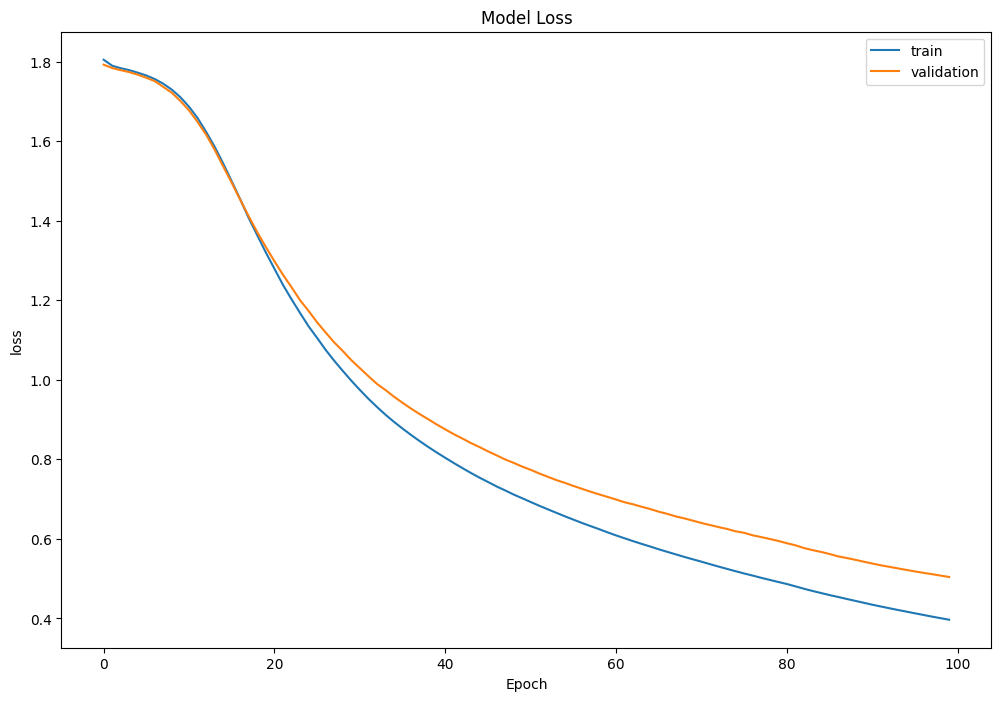

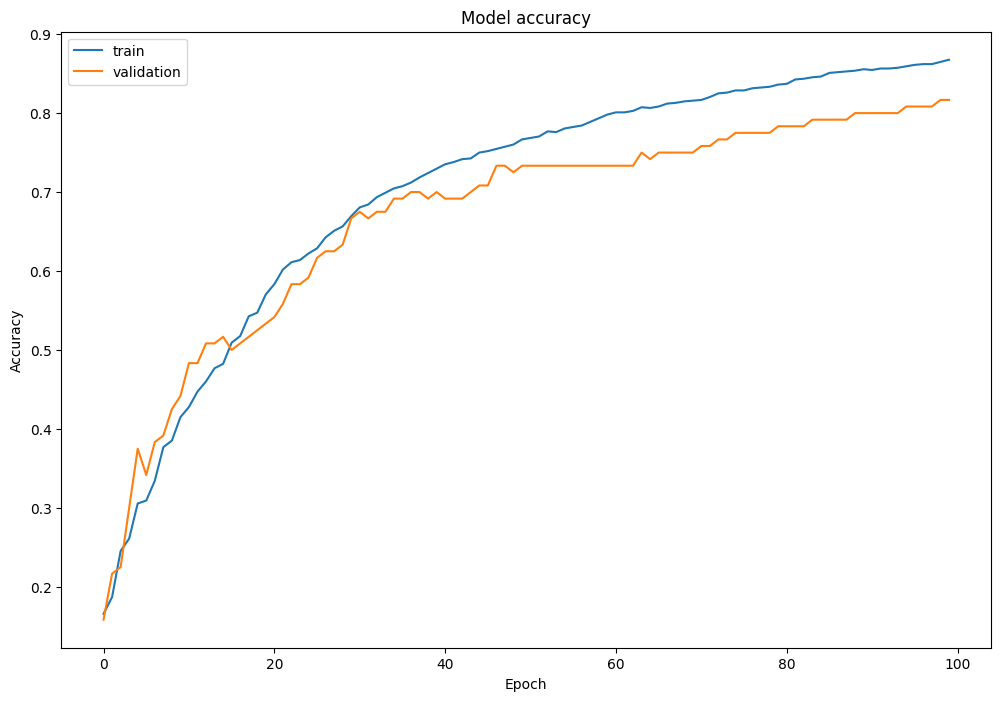

In [23]:
df_loss_acc = pd.DataFrame(history.history)
df_loss = df_loss_acc[['loss', 'val_loss']]
df_loss.rename(columns={'loss' : 'train', 'val_loss' : 'validation'}, inplace=True)
df_acc = df_loss_acc[['accuracy', 'val_accuracy']]
df_acc.rename(columns={'accuracy' : 'train', 'val_accuracy' : 'validation'}, inplace=True)
df_loss.plot(title='Model Loss', figsize=(12, 8)).set(xlabel='Epoch', ylabel='loss')
df_acc.plot(title='Model accuracy', figsize=(12, 8)).set(xlabel='Epoch', ylabel='Accuracy')